In [1]:
import requests
import pandas as pd
import sqlite3
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────
API_KEY = '68ef15b2ac39c37ef459c2168284b0b5'
BASE_URL = 'http://api.openweathermap.org/data/2.5/weather'

# Cities to extract weather data for
CITIES = ['Lagos', 'Abuja', 'London', 'New York', 'Tokyo', 'Paris']

print(f"Configured to extract weather data for {len(CITIES)} cities:")
print(CITIES)

Configured to extract weather data for 6 cities:
['Lagos', 'Abuja', 'London', 'New York', 'Tokyo', 'Paris']


In [3]:
# ── EXTRACT FUNCTION ─────────────────────────────────────────────────────
def extract_weather(city, api_key):
    """Extract weather data for a single city from OpenWeather API"""
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'  # Celsius
    }
    
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code == 200:
        print(f"✅ Successfully extracted data for {city}")
        return response.json()
    else:
        print(f"❌ Failed for {city}: {response.status_code} - {response.json().get('message', '')}")
        return None

# Extract data for all cities
raw_data = []
for city in CITIES:
    data = extract_weather(city, API_KEY)
    if data:
        raw_data.append(data)

print(f"\nSuccessfully extracted data for {len(raw_data)} out of {len(CITIES)} cities.")

❌ Failed for Lagos: 401 - Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
❌ Failed for Abuja: 401 - Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
❌ Failed for London: 401 - Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
❌ Failed for New York: 401 - Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
❌ Failed for Tokyo: 401 - Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
❌ Failed for Paris: 401 - Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.

Successfully extracted data for 0 out of 6 cities.


In [ ]:
import os
from dotenv import load_dotenv

# Load API key securely from .env file
load_dotenv()
API_KEY = os.getenv('OPENWEATHER_API_KEY')

BASE_URL = 'http://api.openweathermap.org/data/2.5/weather'
CITIES = ['Lagos', 'Abuja', 'London', 'New York', 'Tokyo', 'Paris']

print("✅ API Key loaded securely")
print(f"Configured for {len(CITIES)} cities: {CITIES}")

Configured to extract weather data for 6 cities:
['Lagos', 'Abuja', 'London', 'New York', 'Tokyo', 'Paris']


In [5]:
# ── EXTRACT FUNCTION ─────────────────────────────────────────────────────
def extract_weather(city, api_key):
    """Extract weather data for a single city from OpenWeather API"""
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'  # Celsius
    }
    
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code == 200:
        print(f"✅ Successfully extracted data for {city}")
        return response.json()
    else:
        print(f"❌ Failed for {city}: {response.status_code} - {response.json().get('message', '')}")
        return None

# Extract data for all cities
raw_data = []
for city in CITIES:
    data = extract_weather(city, API_KEY)
    if data:
        raw_data.append(data)

print(f"\nSuccessfully extracted data for {len(raw_data)} out of {len(CITIES)} cities.")

✅ Successfully extracted data for Lagos
✅ Successfully extracted data for Abuja
✅ Successfully extracted data for London
✅ Successfully extracted data for New York
✅ Successfully extracted data for Tokyo
✅ Successfully extracted data for Paris

Successfully extracted data for 6 out of 6 cities.


In [6]:
# ── TRANSFORM FUNCTION ───────────────────────────────────────────────────
def transform_weather(raw_data):
    """Transform raw API JSON data into a clean DataFrame"""
    records = []
    
    for data in raw_data:
        record = {
            'city':             data['name'],
            'country':          data['sys']['country'],
            'temperature_c':    data['main']['temp'],
            'feels_like_c':     data['main']['feels_like'],
            'temp_min_c':       data['main']['temp_min'],
            'temp_max_c':       data['main']['temp_max'],
            'humidity_pct':     data['main']['humidity'],
            'pressure_hpa':     data['main']['pressure'],
            'weather_condition':data['weather'][0]['main'],
            'description':      data['weather'][0]['description'],
            'wind_speed_ms':    data['wind']['speed'],
            'visibility_m':     data.get('visibility', None),
            'cloudiness_pct':   data['clouds']['all'],
            'timestamp':        datetime.utcfromtimestamp(data['dt']).strftime('%Y-%m-%d %H:%M:%S'),
            'timezone_offset':  data['timezone']
        }
        records.append(record)
    
    df = pd.DataFrame(records)
    
    # Convert data types
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['temperature_c'] = df['temperature_c'].round(2)
    df['feels_like_c']  = df['feels_like_c'].round(2)
    df['temp_min_c']    = df['temp_min_c'].round(2)
    df['temp_max_c']    = df['temp_max_c'].round(2)
    
    return df

# Run transformation
df_weather = transform_weather(raw_data)
print(f"✅ Transformed data shape: {df_weather.shape}")
df_weather

✅ Transformed data shape: (6, 15)


,city,country,temperature_c,feels_like_c,temp_min_c,temp_max_c,humidity_pct,pressure_hpa,weather_condition,description,wind_speed_ms,visibility_m,cloudiness_pct,timestamp,timezone_offset
0,Lagos,NG,24.37,25.32,24.37,24.37,94,1014,Clouds,overcast clouds,0.90,10000,100,2026-06-18 00:21:52,3600
1,Abuja,NG,23.17,23.92,23.17,23.17,91,1014,Clouds,overcast clouds,1.03,10000,100,2026-06-18 00:30:08,3600
2,London,GB,18.01,18.06,16.72,18.63,84,1018,Clouds,scattered clouds,0.89,10000,25,2026-06-18 00:27:33,3600
3,New York,US,21.33,21.56,20.55,22.79,78,1009,Clouds,overcast clouds,2.24,10000,93,2026-06-18 00:28:56,-14400
4,Tokyo,JP,20.85,21.37,19.25,22.01,91,1011,Rain,heavy intensity rain,0.45,10000,100,2026-06-18 00:19:18,32400
5,Paris,FR,22.19,22.40,20.77,22.49,74,1020,Clouds,few clouds,1.34,10000,13,2026-06-18 00:26:44,7200


In [7]:
# ── LOAD FUNCTION ────────────────────────────────────────────────────────
def load_to_csv(df, filename='weather_data.csv'):
    """Save DataFrame to CSV file"""
    df.to_csv(filename, index=False)
    print(f"✅ Saved to {filename} ({len(df)} rows)")

def load_to_sqlite(df, db_name='weather_data.db', table_name='weather'):
    """Save DataFrame to SQLite database"""
    conn = sqlite3.connect(db_name)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    conn.close()
    print(f"✅ Saved to {db_name} → table: {table_name} ({len(df)} rows)")

# Run load
load_to_csv(df_weather)
load_to_sqlite(df_weather)

print("\n✅ ETL Pipeline complete — data extracted, transformed and loaded!")

✅ Saved to weather_data.csv (6 rows)
✅ Saved to weather_data.db → table: weather (6 rows)

✅ ETL Pipeline complete — data extracted, transformed and loaded!


In [8]:
# ── TASK 4: BASIC ANALYSIS ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print("=== WEATHER SUMMARY ===")
print(df_weather[['city', 'country', 'temperature_c', 'humidity_pct', 
                   'weather_condition', 'wind_speed_ms']].to_string(index=False))

print(f"\n=== KEY FINDINGS ===")
print(f"Hottest city    : {df_weather.loc[df_weather['temperature_c'].idxmax(), 'city']} ({df_weather['temperature_c'].max():.1f}°C)")
print(f"Coldest city    : {df_weather.loc[df_weather['temperature_c'].idxmin(), 'city']} ({df_weather['temperature_c'].min():.1f}°C)")
print(f"Most humid city : {df_weather.loc[df_weather['humidity_pct'].idxmax(), 'city']} ({df_weather['humidity_pct'].max()}%)")
print(f"Least humid city: {df_weather.loc[df_weather['humidity_pct'].idxmin(), 'city']} ({df_weather['humidity_pct'].min()}%)")
print(f"Windiest city   : {df_weather.loc[df_weather['wind_speed_ms'].idxmax(), 'city']} ({df_weather['wind_speed_ms'].max()} m/s)")
print(f"Average temp    : {df_weather['temperature_c'].mean():.1f}°C")

=== WEATHER SUMMARY ===
    city country  temperature_c  humidity_pct weather_condition  wind_speed_ms
   Lagos      NG          24.37            94            Clouds           0.90
   Abuja      NG          23.17            91            Clouds           1.03
  London      GB          18.01            84            Clouds           0.89
New York      US          21.33            78            Clouds           2.24
   Tokyo      JP          20.85            91              Rain           0.45
   Paris      FR          22.19            74            Clouds           1.34

=== KEY FINDINGS ===
Hottest city    : Lagos (24.4°C)
Coldest city    : London (18.0°C)
Most humid city : Lagos (94%)
Least humid city: Paris (74%)
Windiest city   : New York (2.24 m/s)
Average temp    : 21.7°C


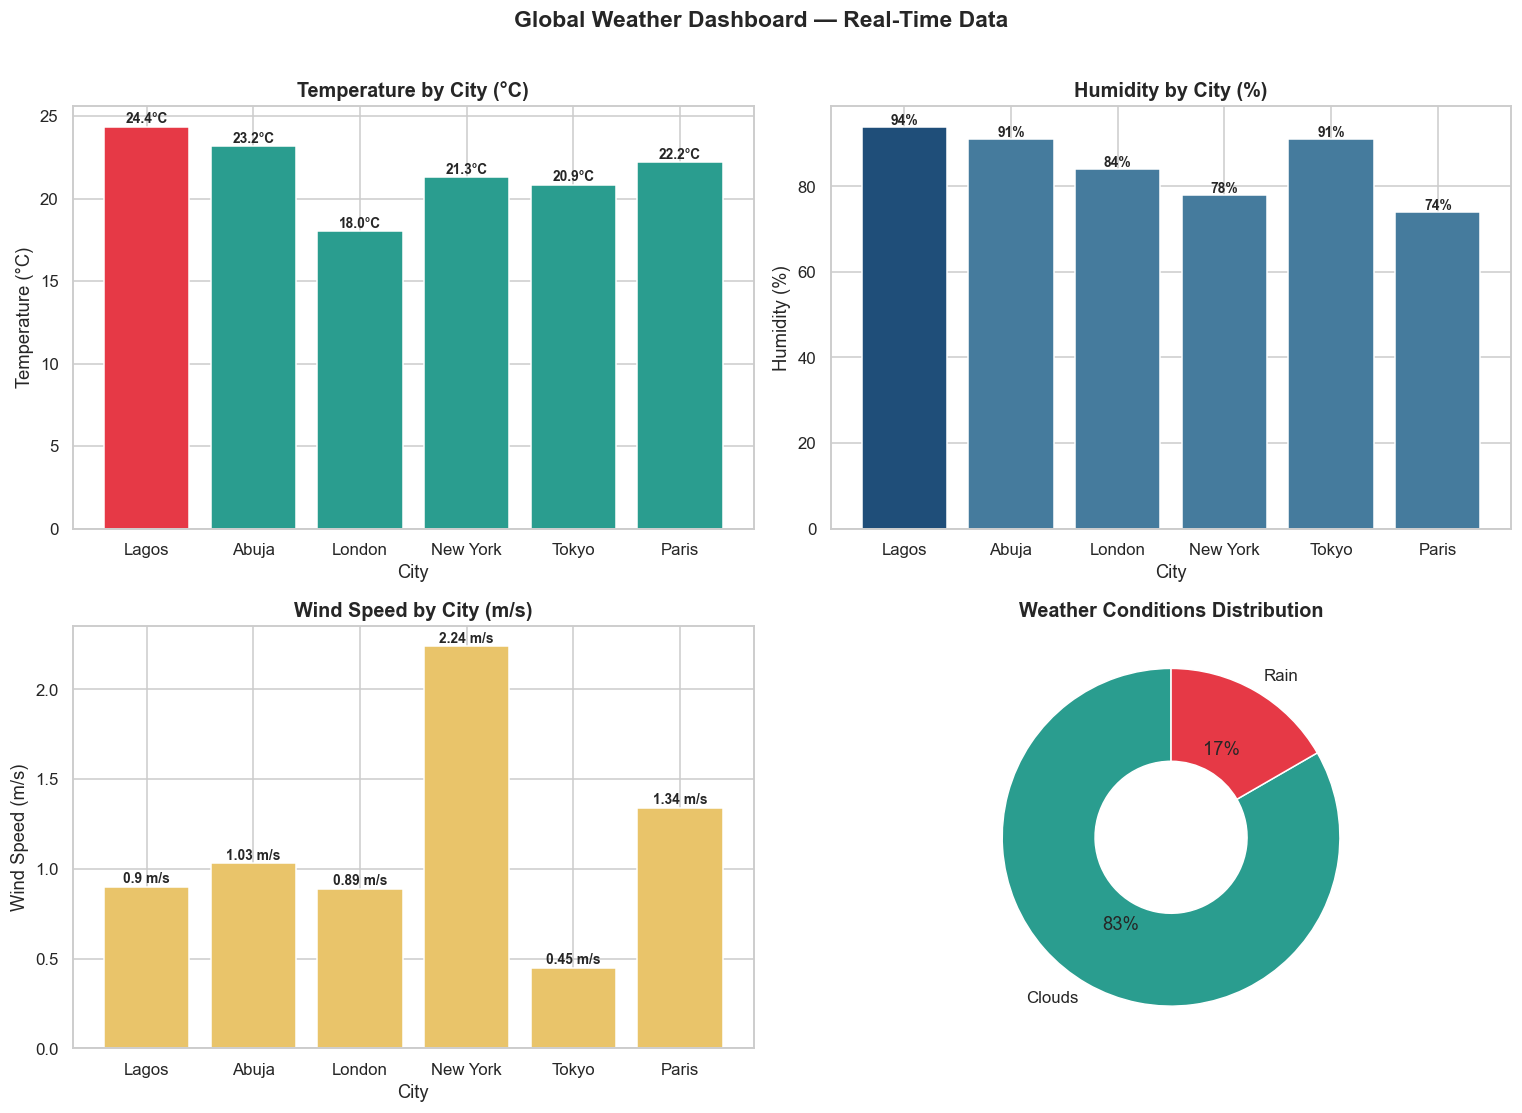

✅ Dashboard saved.


In [9]:
# ── Fig 1: Temperature Comparison ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Temperature by City
colors = ['#e63946' if t == df_weather['temperature_c'].max() 
          else '#2a9d8f' for t in df_weather['temperature_c']]
axes[0,0].bar(df_weather['city'], df_weather['temperature_c'], 
              color=colors, edgecolor='white')
for i, (city, temp) in enumerate(zip(df_weather['city'], df_weather['temperature_c'])):
    axes[0,0].text(i, temp + 0.2, f'{temp:.1f}°C', ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Temperature by City (°C)', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].set_xlabel('City')

# Chart 2 — Humidity by City
colors2 = ['#1f4e79' if h == df_weather['humidity_pct'].max() 
           else '#457b9d' for h in df_weather['humidity_pct']]
axes[0,1].bar(df_weather['city'], df_weather['humidity_pct'],
              color=colors2, edgecolor='white')
for i, (city, hum) in enumerate(zip(df_weather['city'], df_weather['humidity_pct'])):
    axes[0,1].text(i, hum + 0.5, f'{hum}%', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('Humidity by City (%)', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Humidity (%)')
axes[0,1].set_xlabel('City')

# Chart 3 — Wind Speed by City
axes[1,0].bar(df_weather['city'], df_weather['wind_speed_ms'],
              color='#e9c46a', edgecolor='white')
for i, (city, wind) in enumerate(zip(df_weather['city'], df_weather['wind_speed_ms'])):
    axes[1,0].text(i, wind + 0.02, f'{wind} m/s', ha='center', fontsize=9, fontweight='bold')
axes[1,0].set_title('Wind Speed by City (m/s)', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Wind Speed (m/s)')
axes[1,0].set_xlabel('City')

# Chart 4 — Weather Conditions (Donut)
condition_counts = df_weather['weather_condition'].value_counts()
axes[1,1].pie(condition_counts.values, labels=condition_counts.index,
              autopct='%1.0f%%', colors=['#2a9d8f','#e63946'],
              wedgeprops=dict(width=0.55), startangle=90)
axes[1,1].set_title('Weather Conditions Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Global Weather Dashboard — Real-Time Data', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_weather_dashboard.png', bbox_inches='tight')
plt.show()
print("✅ Dashboard saved.")

# Week 7 — Weather ETL Pipeline
## Project Documentation

### Project Overview
This project builds a simple ETL (Extract, Transform, Load) pipeline 
that collects real-time weather data from the OpenWeather API for 
6 major cities around the world, transforms it into a structured 
format, and stores it for analysis.

### Data Source
- **API:** OpenWeather Current Weather API
- **Website:** openweathermap.org
- **Cities:** Lagos, Abuja, London, New York, Tokyo, Paris
- **Data collected:** Temperature, Humidity, Wind Speed, 
  Weather Condition, Pressure, Visibility, Cloudiness

### ETL Process

**Extract**
- Connected to OpenWeather API using Python requests library
- Retrieved JSON weather data for 6 cities simultaneously
- Handled API errors with status code checking

**Transform**
- Parsed nested JSON fields into flat table structure
- Renamed columns with clear descriptive names and units
- Converted Unix timestamps to readable datetime format
- Rounded decimal values to 2 decimal places
- Converted data types appropriately

**Load**
- Saved cleaned data to CSV file (weather_data.csv)
- Saved cleaned data to SQLite database (weather_data.db)

### Tools Used
- Python 3.14
- pandas — data transformation
- requests — API calls
- sqlite3 — database storage
- matplotlib & seaborn — visualisation
- Jupyter Notebook in VS Code

### Key Findings
- Lagos was the hottest city at 24.4°C and most humid at 94%
- London was the coldest city at 18.0°C
- Tokyo was the only city experiencing Rain
- New York had the highest wind speed at 2.24 m/s
- All cities except Tokyo experienced Cloudy conditions
- Average temperature across all 6 cities: 21.7°C